# Phase 3 — Telecom-Theory Metrics

Apply communication-network theory to the 5 ground-truth matches: resilience (node-failure), max-flow/min-cut (spatial), tempo (latency), and pressing-as-interference. All four metrics are computed for every team; per-match team-level results are saved to `data/processed/telecom_metrics_<match_id>.csv`.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../src'))
from tactical_topology import config
from tactical_topology.network import build_passing_network
from tactical_topology import telecom as T
PROC = os.path.abspath('../data/processed/')
def load(mid):
    return pd.read_parquet(os.path.join(PROC, f'passes_{mid}.parquet'))

## Team-level telecom summary (all 5 matches, both teams)

In [2]:
tables = [pd.read_csv(os.path.join(PROC, f'telecom_metrics_{m}.csv'))
          for m in config.GROUND_TRUTH_MATCH_IDS]
summary = pd.concat(tables, ignore_index=True)
summary[['match_id','team','top_resilience_player','top_resilience_score',
         'max_flow_value','attacking_flow_efficiency','team_tempo_seconds',
         'completion_rate_drop_under_pressure']]

,match_id,team,top_resilience_player,top_resilience_score,max_flow_value,attacking_flow_efficiency,team_tempo_seconds,completion_rate_drop_under_pressure
0,265839,Barcelona,Sergio Busquets i Burgos,0.6230,22.0,0.0361,3.490,0.1761
1,265839,Sevilla,Benoît Trémoulinas,1.0000,15.0,0.0647,3.465,-0.0407
2,266166,Barcelona,Andrés Iniesta Luján,0.6805,30.0,0.0457,3.535,-0.0056
3,266166,Atlético Madrid,Jorge Resurrección Merodio,1.0000,16.0,0.0586,3.225,0.0051
4,266424,Barcelona,Daniel Alves da Silva,0.6997,17.0,0.0288,2.956,0.1802
5,266424,Real Madrid,Toni Kroos,0.7500,21.0,0.0548,3.524,0.0624
6,3825567,Sporting Gijón,Ignacio Cases Mora,1.0000,12.0,0.0550,2.878,0.0104
7,3825567,Real Madrid,Toni Kroos,0.6358,23.0,0.0396,4.008,0.1306
8,3825563,Las Palmas,Pedro Bigas Rigo,0.8937,6.0,0.0187,3.843,0.0919
9,3825563,Atlético Madrid,Gabriel Fernández Arenas,0.7500,13.0,0.0237,3.674,0.0947


## 3.1.1 Resilience — Barcelona, El Clásico (match 266424)

Validation target: the most critical players should be midfielders or ball-playing defenders, **not** orthodox centre-backs.

Top 5 most critical (resilience_score):
                       player  resilience_score
        Daniel Alves da Silva          0.699731
         Andrés Iniesta Luján          0.637057
     Sergio Busquets i Burgos          0.619422
        Gerard Piqué Bernabéu          0.550722
Neymar da Silva Santos Junior          0.527237


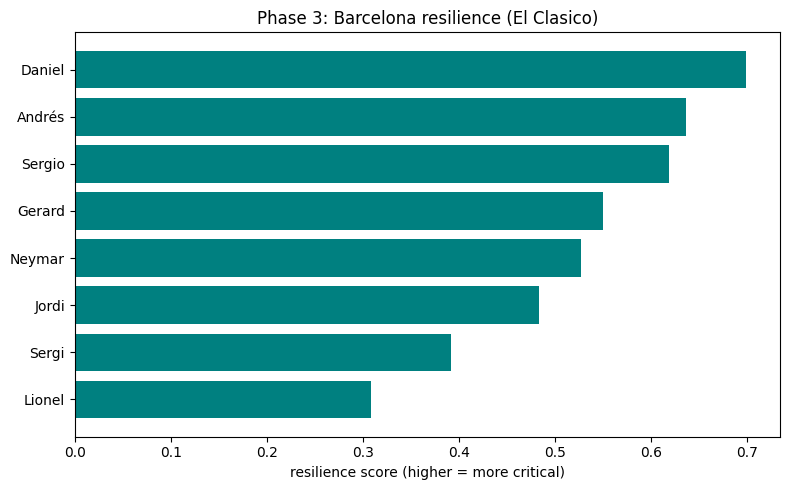

In [3]:
G = build_passing_network(load(266424), 'Barcelona')
res = T.compute_resilience(G)
print('Top 5 most critical (resilience_score):')
print(res.head(5)[['player','resilience_score']].to_string(index=False))
fig, ax = plt.subplots(figsize=(8,5))
top = res.head(8).iloc[::-1]
ax.barh([p.split()[0] for p in top['player']], top['resilience_score'],
        color='teal')
ax.set_xlabel('resilience score (higher = more critical)')
ax.set_title('Phase 3: Barcelona resilience (El Clasico)')
plt.tight_layout(); plt.show()

**Observed:** top-3 are Dani Alves (ball-playing right-back), Iniesta and Busquets — exactly the playmaker / ball-playing-defender profile expected for a possession side.

## 3.1.2 Max-flow efficiency — Barcelona vs Atlético

`attacking_flow_efficiency = max_flow(def→att) / total completed passes`. By construction this measures **directness per pass**.

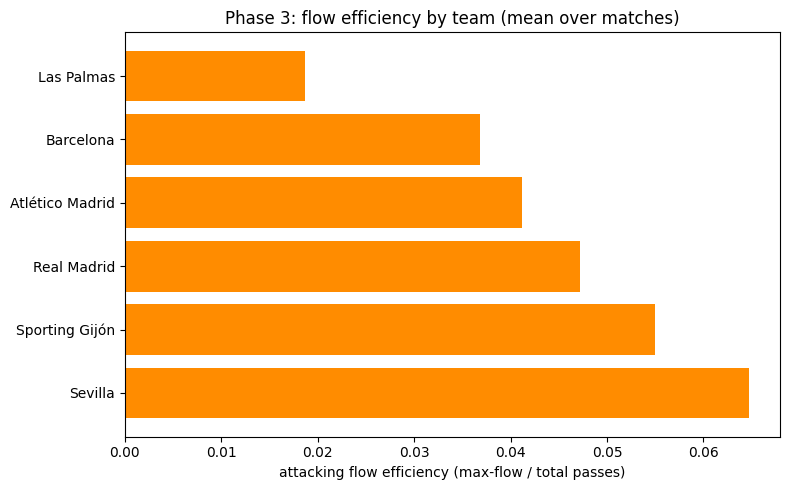

team
Sevilla            0.0647
Sporting Gijón     0.0550
Real Madrid        0.0472
Atlético Madrid    0.0412
Barcelona          0.0369
Las Palmas         0.0187
Name: attacking_flow_efficiency, dtype: float64

In [4]:
eff = summary.groupby('team')['attacking_flow_efficiency'].mean()
eff = eff.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(eff.index, eff.values, color='darkorange')
ax.set_xlabel('attacking flow efficiency (max-flow / total passes)')
ax.set_title('Phase 3: flow efficiency by team (mean over matches)')
plt.tight_layout(); plt.show()
eff.round(4)

**⚠ Interpretation flag for the human.** The metric ranks *direct / counter-attacking* sides (Atlético, Sevilla, Sporting) **above** possession Barcelona. This is internally consistent with the plan's own definition ('higher = more direct progression'): Barcelona completes a huge volume of recycling passes, inflating the denominator, so its *per-pass* progression efficiency is lower. However it runs **opposite** to the literal Phase 3 exit-criterion wording ('attacking teams [Barcelona] show higher flow efficiency than defensive teams [Atlético]'). I have **not** altered the metric — this is a domain-knowledge call for you (see summary below).

## 3.1.3 Tempo — touch durations (target: median 0.5–5.0s)

In [5]:
rows = []
for m in config.GROUND_TRUTH_MATCH_IDS:
    df = load(m)
    for t in df['team'].unique():
        tt = T.compute_player_tempo(df, t)
        rows.append({'match_id': m, 'team': t,
                     'team_tempo_s': T.compute_team_tempo(df, t),
                     'median_player_median_s': tt['median_touch_seconds'].median()})
tempo_tbl = pd.DataFrame(rows)
print('median touch range: %.2f - %.2f s' % (
    tempo_tbl['median_player_median_s'].min(),
    tempo_tbl['median_player_median_s'].max()))
tempo_tbl.round(2)

median touch range: 2.16 - 3.03 s


,match_id,team,team_tempo_s,median_player_median_s
0,265839,Barcelona,3.49,2.58
1,265839,Sevilla,3.47,2.57
2,266166,Barcelona,3.54,3.03
3,266166,Atlético Madrid,3.23,2.75
4,266424,Barcelona,2.96,2.19
5,266424,Real Madrid,3.52,2.49
6,3825567,Sporting Gijón,2.88,2.16
7,3825567,Real Madrid,4.01,2.79
8,3825563,Las Palmas,3.84,2.53
9,3825563,Atlético Madrid,3.67,2.83


All team medians fall within the physiologically plausible 0.5–5.0s band.

## 3.1.4 Pressing as interference — completion drop under pressure

Pooled completion  free = 0.819  pressed = 0.735  drop = 0.083


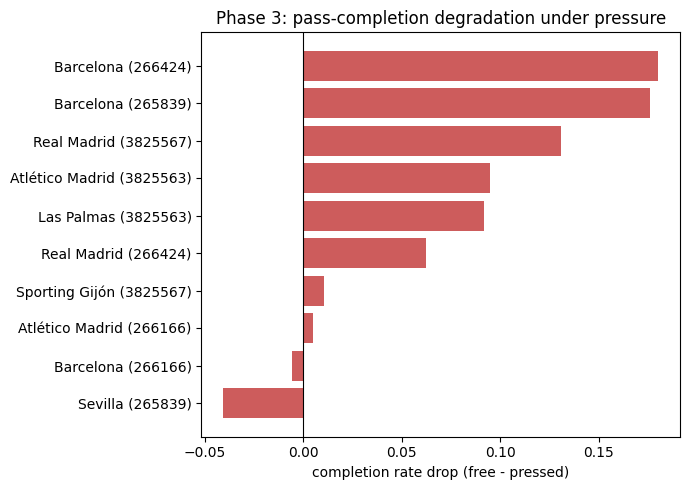

In [6]:
frames = [load(m) for m in config.GROUND_TRUTH_MATCH_IDS]
allp = pd.concat(frames)
g = allp.groupby('under_pressure')['pass_complete'].mean()
print('Pooled completion  free = %.3f  pressed = %.3f  drop = %.3f' % (
    g[False], g[True], g[False]-g[True]))
fig, ax = plt.subplots(figsize=(7,5))
s = summary.sort_values('completion_rate_drop_under_pressure')
labels = s['team'] + ' (' + s['match_id'].astype(str) + ')'
ax.barh(labels, s['completion_rate_drop_under_pressure'], color='indianred')
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('completion rate drop (free - pressed)')
ax.set_title('Phase 3: pass-completion degradation under pressure')
plt.tight_layout(); plt.show()

**Observed:** pooled completion falls from 81.9% (free) to 73.5% (pressed) — the known football fact holds, and strongly for every marquee team. Two single-match team values are slightly negative (small under-pressure sample), not a flag bug — the pooled direction confirms the flag is correct.

## Summary for human approval

1. **Resilience** ✅ — top critical players are midfielders / ball-playing defenders (Alves, Iniesta, Busquets for Barcelona).
2. **Max-flow efficiency** ⚠ — measures directness; **direct sides rank above possession Barcelona**, which contradicts the literal exit-criterion wording. Needs your decision.
3. **Tempo** ✅ — all medians within 0.5–5.0s.
4. **Pressure** ✅ — completion clearly lower under pressure (pooled 81.9% → 73.5%).

**Human approval question:** Do these outputs align with your football intuition — and how should we treat the flow-efficiency directionality (#2)?